<a href="https://colab.research.google.com/github/Tamaki-Baba/text-mining/blob/main/4_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Download wine review corpus from Kaggle(https://www.kaggle.com/zynicide/wine-reviews), then count the number of tokens and words in the ‘description’ column, and plot a graph sorted by word frequency in descendant order.

In [ ]:
import numpy as np
import pandas as pd
from os import path
from PIL import Image
import os
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# download winemag-data-130k-v2.csv from https://www.kaggle.com/zynicide/wine-reviews/data to your PC
# (need to have a Kaggle account)

# upload the file to your google drive
# mount drive (/content/drive)
# then copy winemag-data-130k-v2.csv into VM

# change the path to match your Google Drive
!cp /content/drive/MyDrive/Colab\ Notebooks/MU-TextMining/winemag-data-130k-v2.csv .

In [ ]:
df = pd.read_csv("winemag-data-130k-v2.csv", index_col=0)

In [ ]:
df.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [ ]:
# 必要な列（description列）の抽出
descriptions = df['description']

In [ ]:
# トークン化と頻度の計算
from collections import Counter
import re

def preprocess_text(text):
    # 大文字を小文字に変換し、記号を取り除く
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

# description列のテキストを前処理し、すべての単語をリスト化
all_words = []
for desc in descriptions:
    preprocessed_desc = preprocess_text(desc)
    words = preprocessed_desc.split()  # 空白で単語を分割
    all_words.extend(words)

# 単語の頻度を計算
word_freq = Counter(all_words)

In [ ]:
# 単語頻度を降順にソート
sorted_word_freq = dict(sorted(word_freq.items(), key=lambda x: x[1], reverse=True))

In [ ]:
# 上位の単語と頻度を取得（例: 上位50語）
top_words = list(sorted_word_freq.keys())[:50]
top_frequencies = list(sorted_word_freq.values())[:50]

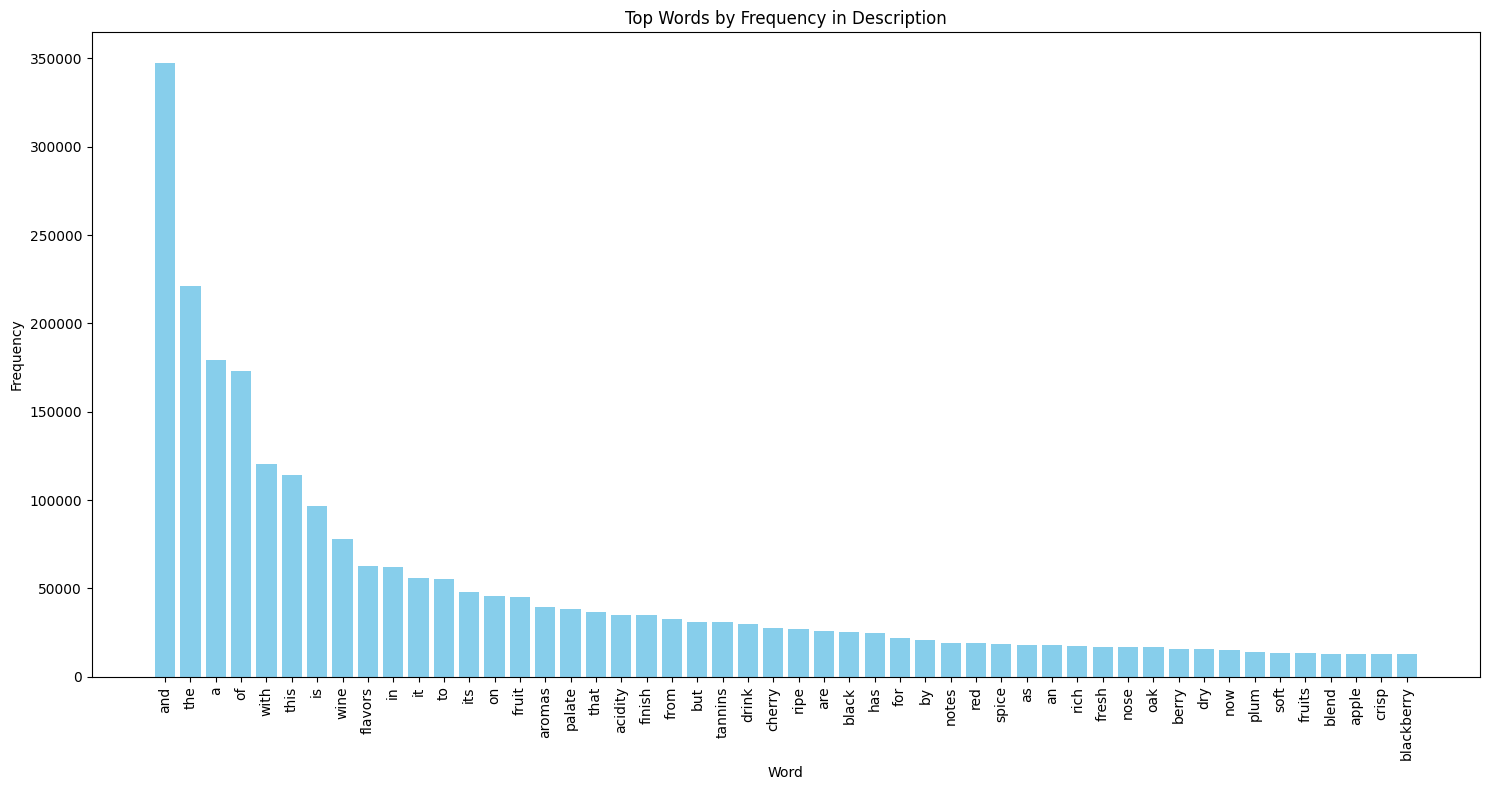

In [ ]:
# グラフをプロット
plt.figure(figsize=(15, 8))
plt.bar(top_words, top_frequencies, color='skyblue')
plt.xticks(rotation=90)
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.title('Top Words by Frequency in Description')
plt.tight_layout()
plt.show()